# Cytokines ML implementation

In [367]:
# Load libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFECV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from boruta import BorutaPy
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Load formatted cytokines data
cytokines_df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260729.csv")

In [8]:
cytokines_df.head()

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,symptomscore,globalhealthstatusql2,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,19.44,75.00,81.62,30.56,stage_I,no,no,alive,1839,alive
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,59.03,16.67,46.11,47.78,stage_IV,no,yes,alive,1721,alive
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,31.25,50.00,57.56,45.68,stage_IV,yes,no,death,48,death
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,68.75,0.00,19.23,94.44,stage_IV,no,yes,death,131,death
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,27.08,75.00,76.67,17.44,stage_II,no,no,alive,1679,alive


In [9]:
cytokines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   sample_names                   212 non-null    str    
 1   sample_id                      212 non-null    str    
 2   cohort                         212 non-null    str    
 3   egf                            212 non-null    float64
 4   ifnalpha2                      212 non-null    float64
 5   ifngamma                       212 non-null    float64
 6   il1alpha                       212 non-null    float64
 7   il1beta                        212 non-null    float64
 8   il4                            212 non-null    float64
 9   il6                            212 non-null    float64
 10  il8                            212 non-null    float64
 11  il10                           212 non-null    float64
 12  mip1alpha                      212 non-null    float64
 13  t

In [10]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "sample_names", "sample_id", "cohort", "ages", "sex", "race", "tobaccouse", "packyears", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [614]:
# Variables to keep from the dataset
# cols_to_keep = ["vegfc", "ages", "il10", "tnfalpha", "ifngamma", "ifnalpha2", "egf", "vegfd", "pni"]

In [341]:
# Specify the predictor variables and target variable
numeric_features = ["ifnalpha2", "tnfalpha", "vegfc", "il10", "vegfd"]
categorical_features = ["lvi", "pni"]
target_var = "survival_2yrs"

In [342]:
# Features (independent variables)
X = cytokines_df[numeric_features + categorical_features]
X

,ifnalpha2,tnfalpha,vegfc,il10,vegfd,lvi,pni
0,25.24,18.74,381.47,3.92,263.05,no,no
1,9.93,25.54,923.75,75.20,237.53,no,yes
2,18.38,22.39,490.19,98.33,130.47,yes,no
3,27.47,28.18,1148.22,20.63,34.22,no,yes
4,13.63,39.61,1113.45,10.63,142.55,no,no
...,...,...,...,...,...,...,...
207,122.36,19.66,289.94,168.84,91.56,yes,yes
208,91.86,26.21,234.20,82.12,65.32,no,no
209,66.46,13.77,144.61,7.41,55.09,yes,yes
210,75.02,16.65,158.81,12.45,21.47,no,no


In [343]:
# Dependent variable (target)
y = cytokines_df[target_var]
y

0      alive
1      alive
2      death
3      death
4      alive
       ...  
207    alive
208    alive
209    alive
210    alive
211    alive
Name: survival_2yrs, Length: 212, dtype: str

In [344]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)

In [345]:
# Features scaling and encoding
numeric_transformer = Pipeline(
    steps=[
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", RobustScaler())
    ]
)

ct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(sparse_output=False), categorical_features),
    ],
    remainder="drop"
).set_output(transform="pandas")

X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

In [346]:
X_train_transformed

,num__ifnalpha2,num__tnfalpha,num__vegfc,num__il10,num__vegfd,cat__lvi_no,cat__lvi_yes,cat__pni_no,cat__pni_yes
10,-1.617137,-0.800484,-0.518099,-0.544051,1.722600,0.0,1.0,0.0,1.0
185,0.446423,-0.341494,-0.576941,-0.374895,-0.657305,0.0,1.0,0.0,1.0
133,0.317707,0.057344,-0.988399,0.678351,0.060253,1.0,0.0,0.0,1.0
177,0.338928,0.350308,-0.220074,0.654942,-0.265220,0.0,1.0,1.0,0.0
117,0.438535,-0.472798,0.133461,-0.237234,-0.714657,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
84,0.955269,1.369274,-0.161231,-0.566083,2.140672,1.0,0.0,1.0,0.0
122,0.603195,-0.140517,0.049736,0.533667,-0.336973,1.0,0.0,1.0,0.0
192,0.298883,-0.943970,-0.117697,-0.394919,-0.043614,1.0,0.0,1.0,0.0
52,-0.954950,1.167610,1.348091,-1.009247,0.828808,1.0,0.0,1.0,0.0


In [347]:
# # Define preprocessing for numeric and categorical features
# numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
# categorical_features = X.select_dtypes(include=["str"]).columns
# target = y.name

# print("Numeric features:", numeric_features)
# print("Categorical features:", categorical_features)
# print("Target variable:", target)

In [348]:
# Encoding dependent variable
le = LabelEncoder()
y_train_transformed = le.fit_transform(y_train)
y_test_transformed = le.transform(y_test)

In [349]:
y_train_transformed

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [350]:
# Splitting the dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_transformed, y_transformed, test_size=0.2, random_state=2026, stratify=y_transformed)

In [351]:
# print(X_train)

In [352]:
# print(X_test)

In [353]:
# # Feature scaling for numeric features
# num_cols = np.arange(X_train.shape[1] - 6, X_train.shape[1])

# ct2 = ColumnTransformer(
#     transformers=[
#         ("log", FunctionTransformer(np.log1p), num_cols),
#         ("num", RobustScaler(), num_cols)
#     ],
#     remainder="passthrough"
# )
# # transformer = FunctionTransformer(np.log1p)
# # rs = RobustScaler()

# X_train = ct2.fit_transform(X_train)
# X_test = ct2.transform(X_test)

In [354]:
# print(X_train)

In [355]:
# print(X_test)

In [371]:
smote = SMOTE(random_state = 2026)
X_res, y_res = smote.fit_resample(X_train_transformed, y_train_transformed)

In [376]:
lr = LogisticRegression(penalty = "l1", solver="liblinear", max_iter=1000, random_state=2026)
lr.fit(X_res, y_res)
y_train_prob = lr.predict_proba(X_train_transformed)[:,1]
y_test_prob = lr.predict_proba(X_test_transformed)[:,1]
y_test_pred = lr.predict(X_test_transformed)
print(lr.score(X_train_transformed, y_train_transformed), lr.score(X_test_transformed, y_test_transformed))
print(roc_auc_score(y_train_transformed, y_train_prob), roc_auc_score(y_test_transformed, y_test_prob))
print(f1_score(y_test_transformed, y_test_pred), recall_score(y_test_transformed, y_test_pred), precision_score(y_test_transformed, y_test_pred))

0.7337278106508875 0.6744186046511628
0.7901360544217687 0.7741935483870968
0.5333333333333333 0.6666666666666666 0.4444444444444444


/mnt/d12t/cytokine_plasma/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [373]:
# Random Forest
rfc = RandomForestClassifier(max_depth = 5, random_state=2026, criterion="log_loss")
rfc.fit(X_res, y_res)
y_train_prob = rfc.predict_proba(X_train_transformed)[:,1]
y_test_prob = rfc.predict_proba(X_test_transformed)[:,1]
y_test_pred = rfc.predict(X_test_transformed)
print(rfc.score(X_train_transformed, y_train_transformed), rfc.score(X_test_transformed, y_test_transformed))
print(roc_auc_score(y_train_transformed, y_train_prob), roc_auc_score(y_test_transformed, y_test_prob))
print(f1_score(y_test_transformed, y_test_pred), recall_score(y_test_transformed, y_test_pred), precision_score(y_test_transformed, y_test_pred))

0.9349112426035503 0.6744186046511628
0.9824829931972789 0.6989247311827957
0.4166666666666667 0.4166666666666667 0.4166666666666667


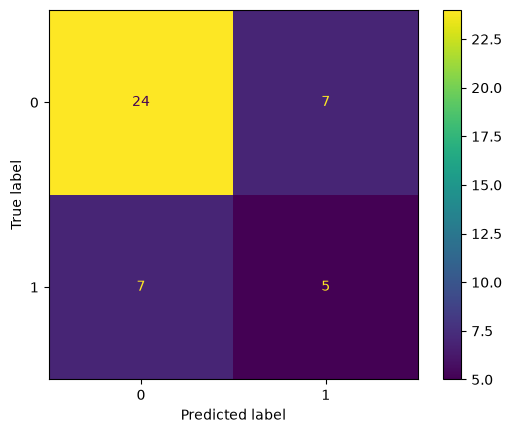

In [358]:
ConfusionMatrixDisplay.from_estimator(rfc, X_test_transformed, y_test_transformed)

In [359]:
# Gradient Boosting
gbc = GradientBoostingClassifier(
    loss = 'exponential',
    n_estimators=500, 
    #min_samples_split = 2,
    #min_samples_leaf = 5,
    max_depth=3,
    #min_impurity_decrease =  0.15, 
    random_state=2026)
gbc.fit(X_res, y_res)
y_train_prob = gbc.predict_proba(X_train_transformed)[:,1]
y_test_prob = gbc.predict_proba(X_test_transformed)[:,1]
y_test_pred = gbc.predict(X_test_transformed)
print(gbc.score(X_train_transformed, y_train_transformed), gbc.score(X_test_transformed, y_test_transformed))
print(roc_auc_score(y_train_transformed, y_train_prob), roc_auc_score(y_test_transformed, y_test_prob))
print(f1_score(y_test_transformed, y_test_pred), recall_score(y_test_transformed, y_test_pred), precision_score(y_test_transformed, y_test_pred))

1.0 0.7209302325581395
1.0 0.75
0.45454545454545453 0.4166666666666667 0.5


In [360]:
# AdaBoost
#for lr in [0.5, 0.4, 0.3, 0.2, 0.1, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01, 0.005, 0.001]:
abc = AdaBoostClassifier(
    n_estimators=500, 
    learning_rate=0.3, 
    random_state=2026)
abc.fit(X_res, y_res)
y_train_prob = abc.predict_proba(X_train_transformed)[:,1]
y_test_prob = abc.predict_proba(X_test_transformed)[:,1]
y_test_pred = abc.predict(X_test_transformed)
print(abc.score(X_train_transformed, y_train_transformed), abc.score(X_test_transformed, y_test_transformed))
print(roc_auc_score(y_train_transformed, y_train_prob), roc_auc_score(y_test_transformed, y_test_prob))
print(f1_score(y_test_transformed, y_test_pred), recall_score(y_test_transformed, y_test_pred), precision_score(y_test_transformed, y_test_pred))

0.7928994082840237 0.6744186046511628
0.8877551020408164 0.760752688172043
0.5 0.5833333333333334 0.4375


In [361]:
# Histogram-based Gradient Boosting
#for lr in [0.5, 0.4, 0.3, 0.2, 0.1, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01, 0.005, 0.001]:
hgb = HistGradientBoostingClassifier(
    random_state=2026,
    learning_rate=0.02
)
hgb.fit(X_res, y_res)
y_train_prob = hgb.predict_proba(X_train_transformed)[:,1]
y_test_prob = hgb.predict_proba(X_test_transformed)[:,1]
y_test_pred = hgb.predict(X_test_transformed)
print(hgb.score(X_train_transformed, y_train_transformed),  hgb.score(X_test_transformed, y_test_transformed))
print(roc_auc_score(y_train_transformed, y_train_prob), roc_auc_score(y_test_transformed, y_test_prob))
print(f1_score(y_test_transformed, y_test_pred), recall_score(y_test_transformed, y_test_pred), precision_score(y_test_transformed, y_test_pred))

0.893491124260355 0.6976744186046512
0.9535714285714286 0.7311827956989247
0.5185185185185185 0.5833333333333334 0.4666666666666667
